# **1. Perkenalan Dataset**


Tahap pertama, Anda harus mencari dan menggunakan dataset dengan ketentuan sebagai berikut:

1. **Sumber Dataset**:  
   Dataset yang digunakan dalam eksperimen ini adalah **AI4I 2020 Predictive Maintenance Dataset**, yang bersumber dari UCI Machine Learning Repository dan diakses melalui platform Kaggle. 

Dataset ini merupakan data telemetri sintetik yang dirancang untuk mencerminkan kondisi keausan dan kegagalan pada mesin industri di dunia nyata. Data ini memuat 10.000 baris log observasi dengan 14 kolom. Fokus utama dari proyek ini adalah menggunakan pembacaan parameter fisik mesin untuk memprediksi apakah mesin tersebut akan mengalami kegagalan (*Machine Failure*).

**Penjelasan Fitur Utama (Pembacaan Sensor & Operasional):**
* **Type:** Kualitas produk yang sedang dikerjakan (L = Low, M = Medium, H = High).
* **Air temperature [K] & Process temperature [K]:** Pembacaan sensor termal untuk memantau suhu udara lingkungan dan suhu operasional mesin dalam satuan Kelvin.
* **Rotational speed [rpm]:** Kecepatan putaran poros motor utama.
* **Torque [Nm]:** Gaya torsi yang dihasilkan mesin.
* **Tool wear [min]:** Waktu degradasi atau tingkat keausan fisik dari mata pisau/alat potong selama proses pemesinan berlangsung.

**Target Klasifikasi:**
* **Machine failure:** Label biner yang menunjukkan status mesin (0 = Normal berjalan dengan baik, 1 = Mengalami kerusakan).

Selain target utama tersebut, dataset ini juga mencatat 5 mode spesifik penyebab kegagalan (*TWF, HDF, PQF, OSF, RNF*) yang akan diabaikan dalam klasifikasi biner utama, namun tetap berguna untuk analisis mendalam terkait anomali sistem mekatronika.


# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [1]:
#Type your code here
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, LabelEncoder

/home/alfdmsr/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [2]:
#Type your code here
file_path = "../ai4i2020_raw/ai4i2020.csv"
df = pd.read_csv(file_path)

display(df.head())

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

=== Info Dataset ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  object 
 2   Type                     10000 non-null  object 
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
dtypes:

UDI                        0
Product ID                 0
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Machine failure            0
TWF                        0
HDF                        0
PWF                        0
OSF                        0
RNF                        0
dtype: int64


=== Statistik Deskriptif Pembacaan Sensor ===


,UDI,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,5000.50000,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900,0.004600,0.011500,0.009500,0.009800,0.00190
std,2886.89568,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981,0.067671,0.106625,0.097009,0.098514,0.04355
min,1.00000,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,2500.75000,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,5000.50000,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
75%,7500.25000,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
max,10000.00000,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000



=== Distribusi Target Kategori (Machine failure) ===


Machine failure
0    9661
1     339
Name: count, dtype: int64

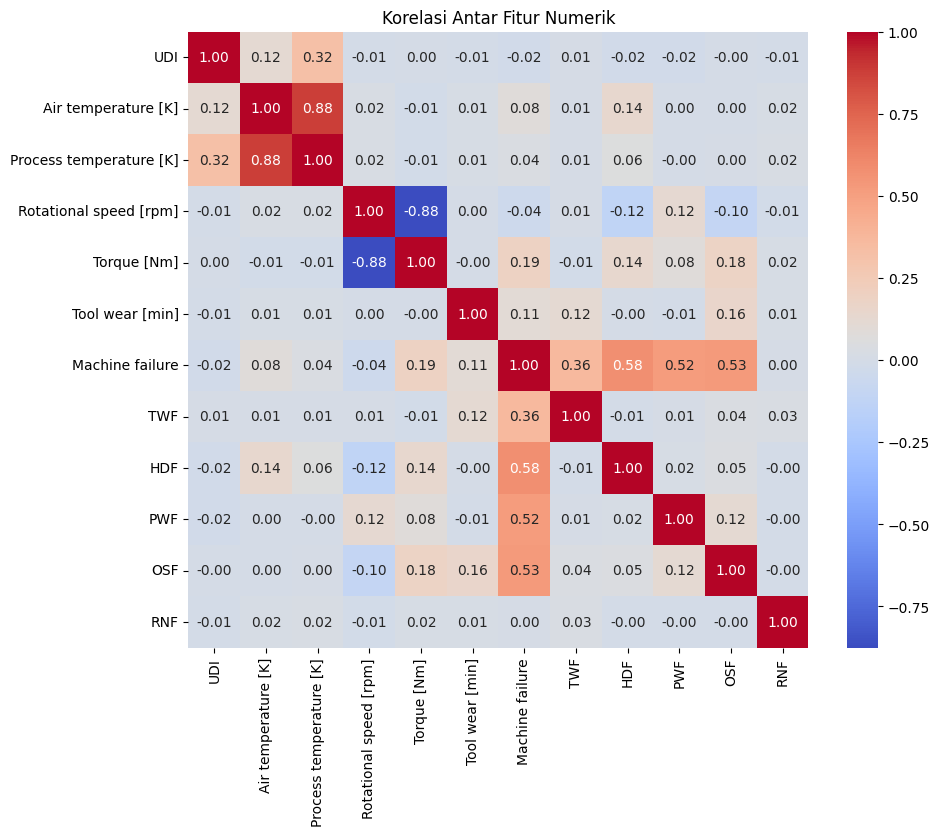

In [5]:
#Type your code here
print("=== Info Dataset ===")
df.info()

print("\n=== Mengecek Missing Values ===")
display(df.isnull().sum())

print("\n=== Statistik Deskriptif Pembacaan Sensor ===")
display(df.describe())

print("\n=== Distribusi Target Kategori (Machine failure) ===")
display(df['Machine failure'].value_counts())

plt.figure(figsize=(10, 8))
sns.heatmap(df.select_dtypes(include=np.number).corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Korelasi Antar Fitur Numerik")
plt.show()

# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

In [8]:
# menghapus kolom yg tidak perlu
kolom_dibuang = ['UDI', 'Product ID', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF']
df_bersih = df.drop(columns=kolom_dibuang)

# memisahkan fitur (X) dan target (y)
X = df_bersih.drop(columns=['Machine failure'])
y = df_bersih['Machine failure']

# Melakukan Encoding pada kolom 'Type' (Kategorikal)
type_mapping = {'L': 0, 'M': 1, 'H': 2}
X['Type'] = X['Type'].map(type_mapping)

# melakukan Scaling pada kolom sensor numerik
kolom_numerik = ['Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]']
scaler = StandardScaler()
X[kolom_numerik] = scaler.fit_transform(X[kolom_numerik])

# menyatukan kembali data untuk disimpan
df_final = X.copy()
df_final['Machine failure'] = y

print("==== Data Setelah Preprocessing ====")
display(df_final.head())

==== Data Setelah Preprocessing ====


,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure
0,1,-0.952389,-0.947360,0.068185,0.282200,-1.695984,0
1,0,-0.902393,-0.879959,-0.729472,0.633308,-1.648852,0
2,0,-0.952389,-1.014761,-0.227450,0.944290,-1.617430,0
3,0,-0.902393,-0.947360,-0.590021,-0.048845,-1.586009,0
4,0,-0.902393,-0.879959,-0.729472,0.001313,-1.554588,0
